In [1]:
# Installation automatique des dependances requises dans le noyau Jupyter actuel.
import subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)
print('Dependances verifiees.')

Dependances verifiees.


# 📢 Étape 7 : Data Storytelling et communication des résultats

Dernière étape du cycle de la donnée, alignée sur le **chapitre 7 du cours** (« Communication des Résultats »). Un modèle, aussi performant soit-il, ne vaut rien s'il ne convainc pas : *« un modèle parfait qui ne convainc pas le comité de direction est un modèle mort »* (cours, §7.1).

Cette étape **traduit** les résultats techniques des notebooks 05 et 06 en un récit clair, destiné à un public non technique (médias sportifs, supporters, décideurs d'une fédération). On mobilise les outils du cours :

- le framework **SCQA** (Situation, Complication, Question, Answer) et la **pyramide de Minto** (la réponse d'abord) pour structurer le récit ;
- le framework **O.I.A.** (Observation → Insight → Action) pour que chaque résultat réponde à la question *« So what ? »* ;
- une communication **honnête de l'incertitude** (§7.3) — la marque d'un expert, pas d'un devin.

### 1. Préparation de l'environnement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Librairies pretes pour le data storytelling.')

Librairies pretes pour le data storytelling.


### 2. Reprise des résultats des notebooks 05 et 06

On recharge les livrables produits par les étapes précédentes du pipeline :

- `cdm2026_qualifies.csv` — les 32 équipes qualifiées et le classement des 12 groupes (notebook 05) ;
- `cdm2026_podium.csv` — le podium issu de la simulation déterministe du bracket (notebook 06) ;
- `cdm2026_titres.csv` — la **probabilité de titre** de chaque équipe, estimée en rejouant le tournoi 20 000 fois (notebook 06).

In [3]:
qualifies = pd.read_csv('../data/processed/cdm2026_qualifies.csv')
podium = pd.read_csv('../data/processed/cdm2026_podium.csv')
titres = pd.read_csv('../data/processed/cdm2026_titres.csv')

vainqueurs = qualifies[qualifies['rang'] == 1].sort_values('groupe')
champion = podium.loc[podium['position'] == 'Champion', 'equipe'].iloc[0]
finaliste = podium.loc[podium['position'] == 'Finaliste', 'equipe'].iloc[0]
troisieme = podium.loc[podium['position'] == '3e place', 'equipe'].iloc[0]
proba_champion = titres.loc[titres['equipe'] == champion, 'proba_titre'].iloc[0]

print(f'{len(qualifies)} equipes qualifiees | {len(vainqueurs)} vainqueurs de groupe')
print(f'Podium predit : {champion} - {finaliste} - {troisieme}')
print(f'Probabilite de titre du favori ({champion}) : {proba_champion:.1%}')

32 equipes qualifiees | 12 vainqueurs de groupe
Podium predit : Brazil - France - Argentina
Probabilite de titre du favori (Brazil) : 23.4%


### 3. Le récit — structurer le message (SCQA + pyramide de Minto)

> **La réponse d'abord.** La pyramide de Minto impose de donner la conclusion *avant* les détails. Voici donc, en une phrase :

> ## 🏆 Le Brésil est le grand favori de la Coupe du Monde 2026.

Le récit complet, structuré selon le framework **SCQA** du cours :

| Étape | Le récit |
|---|---|
| **S — Situation** | La Coupe du Monde 2026 réunit 48 équipes dans un format inédit (12 groupes, 104 matchs). Notre projet a construit un modèle d'apprentissage automatique entraîné sur **plus de 30 000 matchs internationaux** (1993 → 2026). |
| **C — Complication** | Prédire un tournoi à élimination directe est un défi : l'aléa du football, l'avantage du terrain à neutraliser, et 104 matchs où la moindre surprise change tout. |
| **Q — Question** | Peut-on désigner un favori **crédible** et, surtout, **quantifier honnêtement** sa probabilité de soulever le trophée ? |
| **A — Answer** | Oui. Le modèle XGBoost simule l'intégralité du tournoi : il désigne le **Brésil** comme favori — mais dans une compétition qui reste très ouverte. |

#### Traduire la technique en langage clair (le « dictionnaire du Data Translator »)

Le cours insiste : on ne présente jamais une métrique brute à un non-spécialiste, on la **traduit**.

| Métrique technique | Traduction pour le grand public |
|---|---|
| Accuracy = 0.588 | Le modèle voit juste **environ 3 fois sur 5** — là où parier systématiquement sur l'équipe à domicile ne réussit que dans 48 % des cas. |
| ROC-AUC = 0.730 | Le modèle **sépare nettement** les équipes qui vont gagner de celles qui vont perdre (0.5 = pile ou face, 1.0 = parfait). |
| Probabilité de titre = 23 % | Si l'on rejouait la Coupe du Monde 100 fois, le Brésil la gagnerait environ **23 fois** — favori net, mais loin d'une certitude. |

### 4. Visualisations pour la restitution

#### 4.1 Le grand favori — probabilités de titre

La visualisation centrale du projet : la probabilité, pour chaque nation, de remporter la Coupe du Monde 2026 (issue de 20 000 simulations du tournoi).

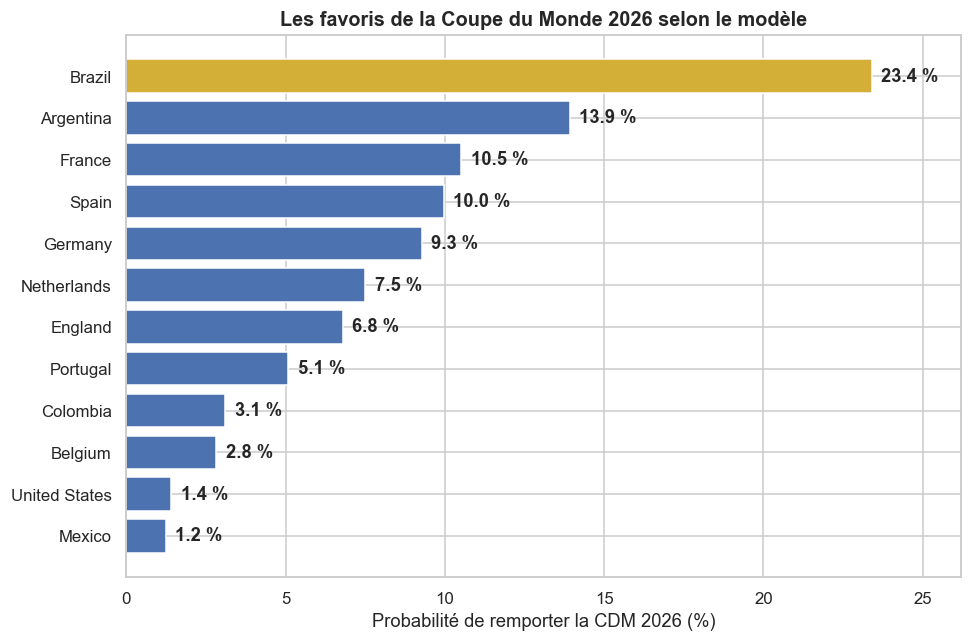

OBSERVATION : le Bresil domine le classement des probabilites de titre.
INSIGHT     : aucune equipe ne depasse 25 % -> le tournoi reste tres ouvert.
ACTION      : communiquer un favori, jamais une certitude (cf. section 5).


In [4]:
top = titres.head(12).iloc[::-1]
couleurs = ['#d4af37' if e == champion else '#4c72b0' for e in top['equipe']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['equipe'], top['proba_titre'] * 100, color=couleurs)
for i, v in enumerate(top['proba_titre']):
    ax.text(v * 100 + 0.3, i, f'{v*100:.1f} %', va='center', fontweight='bold')
ax.set_xlabel('Probabilité de remporter la CDM 2026 (%)')
ax.set_title('Les favoris de la Coupe du Monde 2026 selon le modèle',
             fontweight='bold', fontsize=13)
ax.margins(x=0.12)
fig.tight_layout()
plt.show()

print('OBSERVATION : le Bresil domine le classement des probabilites de titre.')
print('INSIGHT     : aucune equipe ne depasse 25 % -> le tournoi reste tres ouvert.')
print('ACTION      : communiquer un favori, jamais une certitude (cf. section 5).')

#### 4.2 Le podium prédit et les 12 vainqueurs de groupe

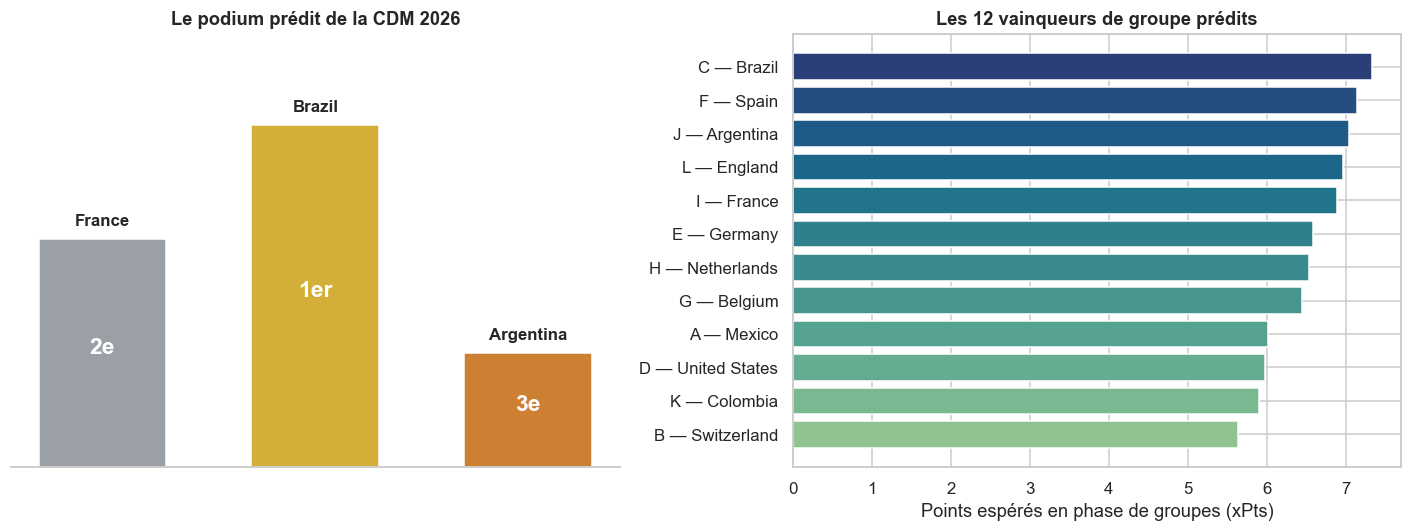

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Podium predit ---
podium_ordre = [finaliste, champion, troisieme]
hauteurs = [2, 3, 1]
couleurs_p = ['#9aa0a6', '#d4af37', '#cd7f32']
axes[0].bar(range(3), hauteurs, color=couleurs_p, width=0.6)
for i, (eq, h) in enumerate(zip(podium_ordre, hauteurs)):
    axes[0].text(i, h + 0.12, eq, ha='center', fontweight='bold', fontsize=11)
    axes[0].text(i, h / 2, ['2e', '1er', '3e'][i], ha='center',
                 color='white', fontweight='bold', fontsize=15)
axes[0].set_ylim(0, 3.8)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_title('Le podium prédit de la CDM 2026', fontweight='bold', fontsize=12)
for s in ['top', 'right', 'left']:
    axes[0].spines[s].set_visible(False)

# --- 12 vainqueurs de groupe ---
vg = vainqueurs.sort_values('xPts')
axes[1].barh(vg['groupe'] + ' — ' + vg['equipe'], vg['xPts'],
             color=sns.color_palette('crest', len(vg)))
axes[1].set_xlabel('Points espérés en phase de groupes (xPts)')
axes[1].set_title('Les 12 vainqueurs de groupe prédits', fontweight='bold', fontsize=12)

fig.tight_layout()
plt.show()

#### 4.3 Un tableau de bord interactif pour la restitution

Le cours (§7.2) rappelle qu'*« en 2026, fournir un rapport PDF statique à un décideur n'est plus suffisant »*. Les graphiques ci-dessus, parfaits pour un rapport écrit, gagnent à être déclinés en **tableau de bord interactif** permettant le *drill-down* : survol pour lire une valeur, filtrage par tour, suivi du parcours d'une équipe, navigation par thème.

C'est l'objet du livrable `dashboard.html`. Ses graphiques sont construits avec **Plotly** (la bibliothèque de graphiques web interactifs recommandée par le cours) ; il s'agit d'un **tableau de bord autonome** — un fichier HTML unique, ouvrable dans n'importe quel navigateur, sans installation ni serveur. Il organise les résultats du projet en **sept vues** accessibles depuis une barre latérale :

- **Vue d'ensemble** — course au titre, probabilité du champion et part d'incertitude ;
- **Jeu de données** — volume de matchs, buts par décennie, répartition des résultats et poids de l'écart de classement FIFA ;
- **Modèle** — comparaison Baseline / Random Forest / XGBoost, variables influentes, classes mal détectées, et explication des choix de variables et d'hyperparamètres ;
- **Phase de groupes** — les 12 groupes officiels (tirage du 5 décembre 2025) avec drapeaux et classement projeté de chaque équipe ;
- **Phase finale** — bracket complet « route vers la finale » des 16ᵉˢ jusqu'au champion, avec drapeaux et suivi interactif du parcours d'une équipe ;
- **Équipes** — probabilités de titre et meilleurs vainqueurs de groupe (xPts) ;
- **Décision** — trois messages clés et récapitulatif des indicateurs.

Tous les chiffres affichés sont chargés depuis les fichiers produits par les notebooks 05 et 06 (`cdm2026_qualifies.csv`, `cdm2026_titres.csv`, `cdm2026_podium.csv`) : le tableau de bord est donc strictement cohérent avec ce rapport. Il constitue le **livrable de communication** du projet, au-delà du rapport PDF.

### 5. Transparence et communication de l'incertitude (§7.3 du cours)

> *« Un dirigeant préférera toujours un expert qui maîtrise ses marges d'erreur plutôt qu'un devin qui se trompe avec aplomb. »* — chapitre 7 du cours.

Annoncer « le Brésil sera champion » serait une **faute de communication**. Le résultat honnête est probabiliste : le Brésil est favori **avec 23 % de chances** — ce qui signifie qu'il échouerait plus de **3 fois sur 4**. Le graphique ci-dessous montre à quel point le tournoi reste ouvert.

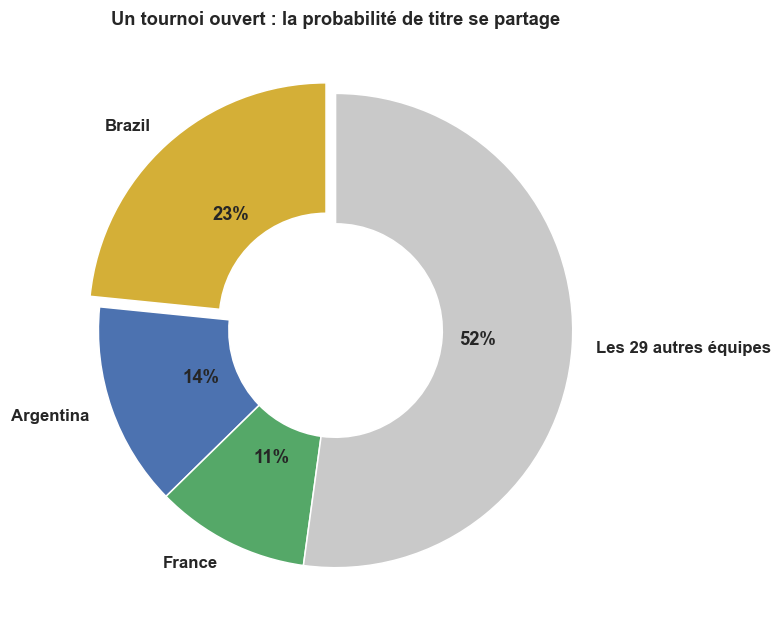

Meme le favori (Brazil) ne concentre que 23% des chances.


In [6]:
top3 = titres.head(3)
reste = titres['proba_titre'].iloc[3:].sum()
parts = list(top3['proba_titre']) + [reste]
labels = list(top3['equipe']) + [f'Les {len(titres)-3} autres équipes']
explode = [0.06, 0, 0, 0]
couleurs_d = ['#d4af37', '#4c72b0', '#55a868', '#c9c9c9']

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(parts, labels=labels, autopct='%1.0f%%', startangle=90,
       explode=explode, colors=couleurs_d, wedgeprops={'width': 0.55},
       textprops={'fontweight': 'bold'})
ax.set_title("Un tournoi ouvert : la probabilité de titre se partage",
             fontweight='bold', fontsize=12)
plt.show()

print(f'Meme le favori ({champion}) ne concentre que {parts[0]:.0%} des chances.')

#### Les deux visages de l'incertitude, et les limites du modèle

Le cours distingue deux incertitudes — utile pour expliquer *pourquoi* la prédiction n'est pas une certitude :

- **Incertitude aléatoire** (irréductible) : le football est imprévisible par nature — un poteau, un carton rouge, un exploit individuel. Aucune donnée ne supprimera jamais cette part de hasard.
- **Incertitude épistémique** (réductible) : elle vient des **limites de notre modèle**, et *peut* être réduite :
  - le modèle ignore les **compositions d'équipe** (blessures, suspensions, forme des joueurs clés) ;
  - il prédit une **issue** (victoire/nul/défaite), pas un score, ni la dynamique d'un tournoi ;
  - il ne sait quasiment pas prévoir les **matchs nuls** (rappel ≈ 3 %, vu au notebook 06) ;
  - les **données récentes** (amicaux 2025-2026, qualifications) pèsent autant qu'un match de 1995.

**Pistes d'amélioration** (réduction de l'incertitude épistémique) : intégrer les effectifs réels, pondérer les matchs par leur ancienneté, ajouter des données de performance des joueurs.

### 6. Recommandations et conclusion

En appliquant une dernière fois le framework **O.I.A.** du cours à l'ensemble du projet :

**🔎 Observation.** À partir de 30 000+ matchs internationaux, un modèle XGBoost (précision 59 %, ROC-AUC 0.73) a simulé toute la Coupe du Monde 2026, de la phase de groupes à la finale.

**💡 Insight.** Le Brésil ressort favori (**23 % de probabilité de titre**), devant l'Argentine (14 %) et la France (11 %). Mais aucune équipe ne dépasse 25 % : **la compétition est ouverte**, et les variables les plus prédictives sont l'écart de classement FIFA et la performance récente pondérée par la force des adversaires.

**🎯 Action — recommandations.**

1. **Pour une rédaction sportive / des supporters** : communiquer le Brésil comme favori, *toujours* assorti de sa probabilité (23 %) — un récit honnête et engageant, pas une fausse certitude.
2. **Pour une fédération** : utiliser les probabilités de qualification par tour comme outil d'**aide à la préparation** (identifier les adversaires probables).
3. **Pour la suite du projet** : enrichir le **tableau de bord interactif** (`dashboard.html`) de nouvelles vues et compléter le modèle avec les données d'effectifs pour réduire l'incertitude épistémique.

---

#### 🌉 Conclusion du projet

Ce notebook clôt le **cycle complet de la donnée** : acquisition → nettoyage → visualisation → analyse exploratoire → modélisation → évaluation → **communication**. Parti d'un simple fichier de résultats de matchs, le projet aboutit à une prédiction chiffrée, évaluée et — surtout — **honnêtement communiquée** du vainqueur de la Coupe du Monde 2026.

> 🏆 **Prédiction finale : le Brésil, favori de la Coupe du Monde 2026 (23 % de probabilité de titre).**